In [1]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [2]:
# Q1 manual linear regression
def linear_regression(X, Y):
    def std(v):
        return np.sqrt(np.sum((v - np.mean(v)) ** 2) / len(v))
    def correlation(x, y):
        return (np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sqrt(np.sum(((x - np.mean(x)) ** 2)) * np.sum(((y - np.mean(y)) ** 2)))) if std(x) != 0 and std(y) != 0 else 0
    sd_x = std(X)
    sd_y = std(Y)
    corr = correlation(X, Y)
    b1 = corr * (sd_y / sd_x) if sd_x != 0 else 0
    b0 = np.mean(Y) - b1 * np.mean(X)
    return b1, b0

In [3]:
# Compare with sklearn's LinearRegression
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 7, 11])
b1, b0 = linear_regression(x, y)
print(f"Manual Linear Regression: b1 = {b1}, b0 = {b0}")
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
print(f"Sklearn Linear Regression: b1 = {model.coef_[0]}, b0 = {model.intercept_}")

Manual Linear Regression: b1 = 2.1999999999999997, b0 = -1.0
Sklearn Linear Regression: b1 = 2.2000000000000006, b0 = -1.0000000000000018


In [4]:
# Q2 Load Kirby21 dataset
df = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/refs/heads/main/book/assetts/kirby21AllLevels.csv")
left_telecephalon = df[df['roi'] == "Telencephalon_L"][['id','volume']].rename(columns={'volume': 'left'})
right_telecephalon = df[df['roi'] == "Telencephalon_R"][['id','volume']].rename(columns={'volume': 'right'})
data = pd.merge(left_telecephalon, right_telecephalon, on='id')

In [5]:
# Left to Right Linear regression
x1 = data['left'].values
y1 = data['right'].values
model1 = LinearRegression()
model1.fit(x1.reshape(-1, 1), y1)
b1, b0 = model1.coef_[0], model1.intercept_
print(f"Left to Right Linear Regression: b1 = {b1}, b0 = {b0}")

Left to Right Linear Regression: b1 = 1.0442415398322413, b0 = -13875.944799423858


In [6]:
# Right to Left Linear regression
x2 = data['right'].values
y2 = data['left'].values
model2 = LinearRegression()
model2.fit(x2.reshape(-1, 1), y2)
b1, b0 = model2.coef_[0], model2.intercept_
print(f"Right to Left Linear Regression: b1 = {b1}, b0 = {b0}")

Right to Left Linear Regression: b1 = 0.9500552111008125, b0 = 17150.43104580429


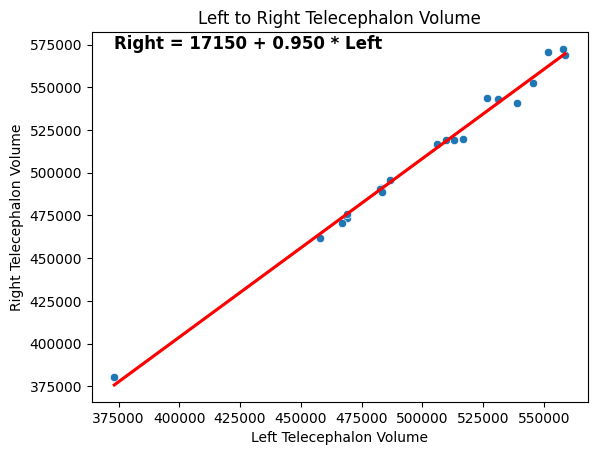

In [7]:
# scatter plot with regression line
sns.scatterplot(x='left', y='right', data=data)
sns.regplot(x='left', y='right', data=data, scatter=False, color='red', ci=None)
plt.title("Left to Right Telecephalon Volume")
plt.xlabel("Left Telecephalon Volume")
plt.ylabel("Right Telecephalon Volume")
plt.text(data['left'].min(), data['right'].max(), f"Right = {b0:.0f} + {b1:.3f} * Left", 
         fontsize=12, fontweight='bold',)
plt.show()

Q3

In a regression through the origin ( Y = bX + e ), the Ordinary Least Squares estimate for the slope $b$ is given by: $$\hat{b} = \frac{\sum X_i Y_i}{\sum X_i^2}$$
If we replace $X$ with $X' = cX$, the new estimate $\hat{b}'$ becomes: $$\hat{b}' = \frac{\sum (cX_i) Y_i}{\sum (cX_i)^2} = \frac{c \sum X_i Y_i}{c^2 \sum X_i^2} = \frac{1}{c} \hat{b}$$

Q4

Group 2 ($X_i=0$)

The regression equation simplifies to $\hat{Y}_{G2} = \beta_0 + e$. To fit the model with least squares, we need to find a $\beta_0$ to minimize $\sum(\hat{Y} - Y_i^{G2})^2 = \sum(\beta_0 + e - Y_i^{G2})^2$

Take the derivative with respect to $\beta_0$ and let it be zero: $$ \frac{d}{d\beta_0}\sum(\beta_0 + e - Y_i^{G2})^2 = 2\sum(\beta_0 + e - Y_i^{G2}) = 0 $$

So $$\sum_{i=1}^{n}(\beta_0 + e) = \sum_{i=1}^{n}Y_i^{G2} $$
$$n(\beta_0 + e) = \sum_{i=1}^{n}Y_i^{G2} $$
$$\beta_0 = \frac{1}{n}\sum_{i=1}^{n}Y_i^{G2} - e = \bar{Y}_{G2} - e$$

Group 1 ($X_i=1$)

The regression equation is $\hat{Y}_{G1} = \beta_0 + \beta_1 + e = \bar{Y}_{G2} + \beta_1$

Repeat the same procedure in group 2 can get: $$\beta_1 = \bar{Y}_{G1} - \bar{Y}_{G2}$$

Now we get the model: $$ \bar{Y_i} = (\bar{Y}_{G1} - \bar{Y}_{G2})X_i + \bar{Y}_{G2} $$

Predicted value for those in Group 1 ($X_i=1$) is $ \bar{Y_i} = (\bar{Y}_{G1} - \bar{Y}_{G2}) \cdot 1 + \bar{Y}_{G2} = \bar{Y}_{G1}$

Predicted value for those in Group 2 ($X_i=0$) is $ \bar{Y_i} = (\bar{Y}_{G1} - \bar{Y}_{G2}) \cdot 0 + \bar{Y}_{G2} = \bar{Y}_{G2}$

In [8]:
# Q4 Validation
y_g1 = np.array([1, 2, 3, 4, 5])
y_g2 = np.array([2, 3, 5, 7, 11])
y = np.concatenate([y_g1, y_g2])
x = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0]).reshape(-1, 1)

model = LinearRegression().fit(x, y)

print(f"Group 1 Mean: {y_g1.mean()}, Prediction for X=1: {model.predict([[1]])[0]:.2f}")
print(f"Group 2 Mean: {y_g2.mean()}, Prediction for X=0: {model.predict([[0]])[0]:.2f}")

Group 1 Mean: 3.0, Prediction for X=1: 3.00
Group 2 Mean: 5.6, Prediction for X=0: 5.60


Q5

When we divide $X$ and $Y$ by their respective standard deviations
$$X' = \frac{X}{SD_X}$$
$$Y' = \frac{Y}{SD_Y}$$

Calculate new standard deviations
$$SD_{X'} = \sqrt {\frac{1}{n} \sum_{i=1}^{n}(X'_i - \bar{X'})^2} = \sqrt {\frac{1}{n} \sum_{i=1}^{n}(\frac{X_i}{SD_X} - \frac{\bar{X}}{SD_X})^2} = \frac{1}{SD_X} \sqrt {\frac{1}{n} \sum_{i=1}^{n}(X_i-\bar{X})^2} = 1$$

Similarly
$$SD_{Y'} = 1$$

For linear regression $Y' = \beta_1'X' + \beta_0'$
$$\beta_1' = Cor(X',Y') \cdot \frac{SD_Y'}{SD_X'} = Cor(X',Y')$$

Regressing X on Y is the same

In [9]:
# Q7 load dataset
df = pd.read_csv("https://raw.githubusercontent.com/bcaffo/ds4bme_intro/master/data/oasis.csv")
columns = ['FLAIR', 'PD', 'T1', 'T2']
oasis = df[columns + ['GOLD_Lesions']]

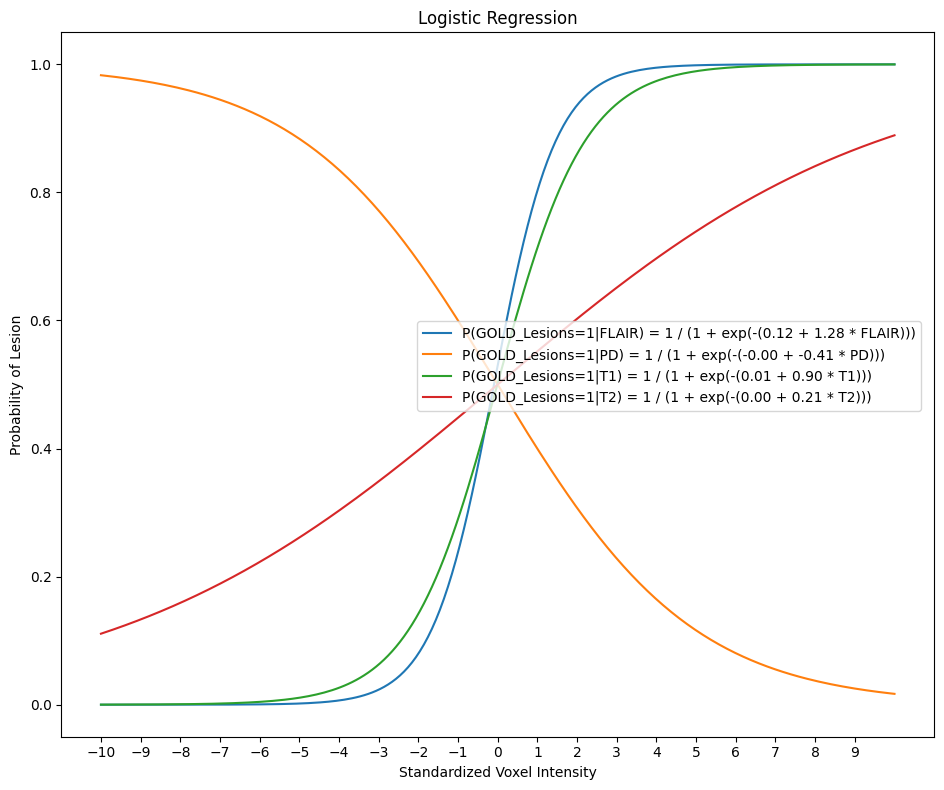

In [10]:
# Logistic regression and plot
x_plot = np.linspace(-10, 10, 200).reshape(-1, 1)
plt.figure(figsize=(10, 8))
for col in columns:
    df[col + '_norm'] = (df[col] - df[col].mean()) / df[col].std()
    model = LogisticRegression()
    x = df[[col + '_norm']].values
    y = df['GOLD_Lesions'].values
    model.fit(x, y)
    b0 = model.intercept_[0]
    b1 = model.coef_[0][0]
    y_prob = model.predict_proba(x_plot)[:, 1]
    equation = f"P(GOLD_Lesions=1|{col}) = 1 / (1 + exp(-({b0:.2f} + {b1:.2f} * {col})))"
    plt.plot(x_plot, y_prob, label=equation)


plt.title("Logistic Regression")
plt.xlabel("Standardized Voxel Intensity")
plt.ylabel("Probability of Lesion")
plt.xticks(np.arange(-10, 10, 1))
plt.legend(loc='upper left', bbox_to_anchor=(0.4, 0.6))
plt.tight_layout()
plt.show()